# Clustering: Modelos Probabilísticos (GMM) y Jerárquicos

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/03_machine_learning/14_clustering_jerarquico_y_gmm.ipynb)

## Objetivos


- Superar las limitaciones geométricas de K-Means utilizando **Gaussian Mixture Models (GMM)** para modelar clusters elípticos y de varianza desigual.
- Comprender la diferencia entre *Hard Clustering* (K-Means) y *Soft Clustering* (GMM).
- Implementar **Clustering Jerárquico Aglomerativo** para descubrir taxonomías en los datos sin predefinir $K$.
- Aprender a leer e interpretar un **Dendrograma** para tomar decisiones de negocio basadas en la similitud.



## Prerrequisitos


- Entendimiento de las limitaciones de K-Means (supuesto de esfericidad).
- Haber completado: [Clustering: K-Means, Métricas y Limitaciones Geométricas](13_kmeans_y_sus_limitaciones.ipynb).

---



## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
from utils.data import load_dataset
setup_plot_style()

## Introducción Teórica


En el notebook anterior, vimos cómo K-Means fracasaba al intentar agrupar datos que tenían formas alargadas (anisotrópicas) o densidades diferentes. Esto ocurre porque K-Means usa distancias rígidas y asume que todos los clusters son esferas perfectas del mismo tamaño.

Para resolver esto, la ingeniería recurre a dos enfoques radicalmente distintos: la probabilidad y la jerarquía.

### 1. Gaussian Mixture Models (GMM) y el *Soft Clustering*



Un Modelo de Mezcla Gaussiana (GMM) asume que los datos provienen de una mezcla de varias distribuciones normales (campanas de Gauss) superpuestas.

A diferencia de K-Means, que traza fronteras rígidas (*Hard Clustering*), GMM calcula la **probabilidad** de que un punto pertenezca a cada cluster (*Soft Clustering*). Además, GMM no solo calcula el centro del cluster (la media), sino también su forma y orientación (la matriz de covarianza). Esto le permite estirarse y rotar para formar **elipses** perfectas que se adaptan a los datos.



### 2. Clustering Jerárquico (Aglomerativo)



¿Qué pasa si no se tiene idea de cuántos clusters hay ($K$) y las métricas como *Silhouette* no son concluyentes?

El Clustering Jerárquico Aglomerativo (*Bottom-Up*) no pide $K$. Funciona así:
1. Comienza asumiendo que cada punto individual es su propio cluster (Si se tienen 100 puntos, se tienen 100 clusters).
2. Encuentra los dos clusters más cercanos y los fusiona en uno solo.
3. Repite el paso 2 iterativamente hasta que todos los puntos estén fusionados en un único y gigantesco cluster raíz.

El resultado de este proceso se visualiza en un árbol llamado **Dendrograma**, que nos permite ver la taxonomía completa de los datos y decidir visualmente dónde "cortar" el árbol.

## Desarrollo e Implementación 1: GMM



Vamos a recrear el dataset de "grupos alargados" que destruyó a K-Means en el notebook anterior, y vemos cómo GMM lo resuelve sin esfuerzo.



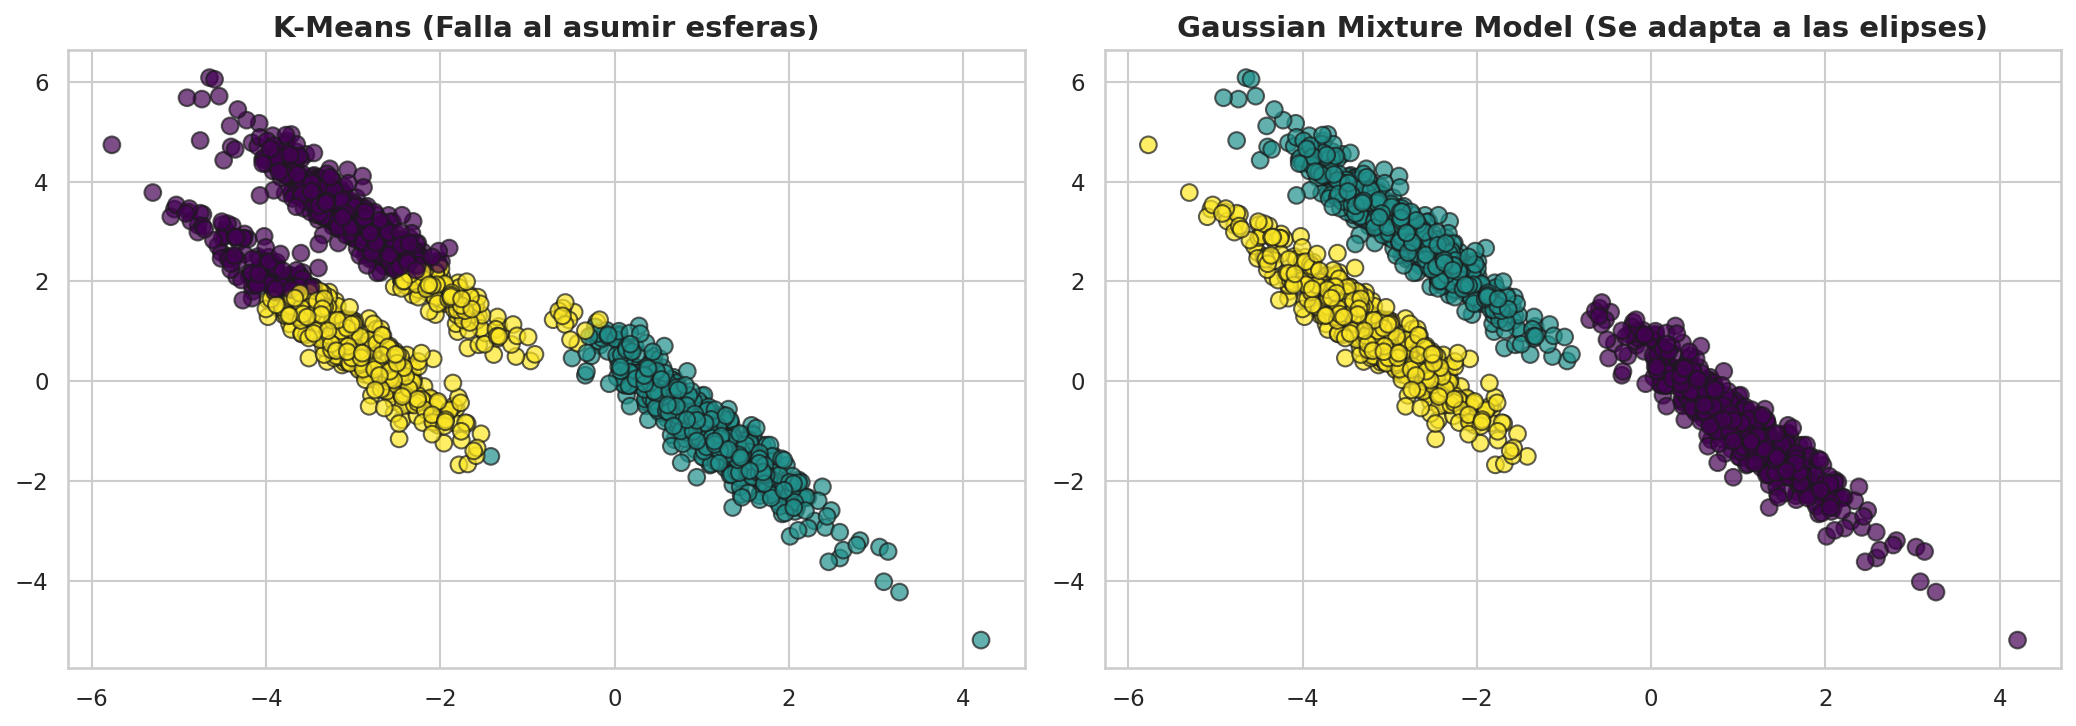

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

# 1. Generamos el dataset problemático (Grupos Alargados / Anisotrópicos)
n_samples = 1500
random_state = 170
X_blobs, y_blobs = make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]
X_aniso = np.dot(X_blobs, transformation)

# 2. Entrenamos K-Means (El que falla en este caso)
kmeans = KMeans(n_clusters=3, n_init=10, random_state=random_state)
y_kmeans = kmeans.fit_predict(X_aniso)

# 3. Entrenamos GMM (Ideal para este tipo de distribuciones)
# covariance_type='full' permite que cada cluster tenga su propia forma elíptica y rotación
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=random_state)
y_gmm = gmm.fit_predict(X_aniso)

# Visualizamos la comparativa
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].scatter(X_aniso[:, 0], X_aniso[:, 1], c=y_kmeans, cmap='viridis', edgecolors='k', alpha=0.7)
axs[0].set_title("K-Means (Falla al asumir esferas)")

axs[1].scatter(X_aniso[:, 0], X_aniso[:, 1], c=y_gmm, cmap='viridis', edgecolors='k', alpha=0.7)
axs[1].set_title("Gaussian Mixture Model (Se adapta a las elipses)")

plt.tight_layout()
plt.show()


¡Problema resuelto! GMM entendió la estructura de covarianza de los datos y agrupó los "cigarrillos" perfectamente.



## Desarrollo e Implementación 2: Dendrograma


Ahora, pasamos a un problema real donde no sabemos cuántos grupos hay. Usamos una muestra del **Wine Clustering Dataset** (reducida a 50 vinos para que el árbol sea legible).

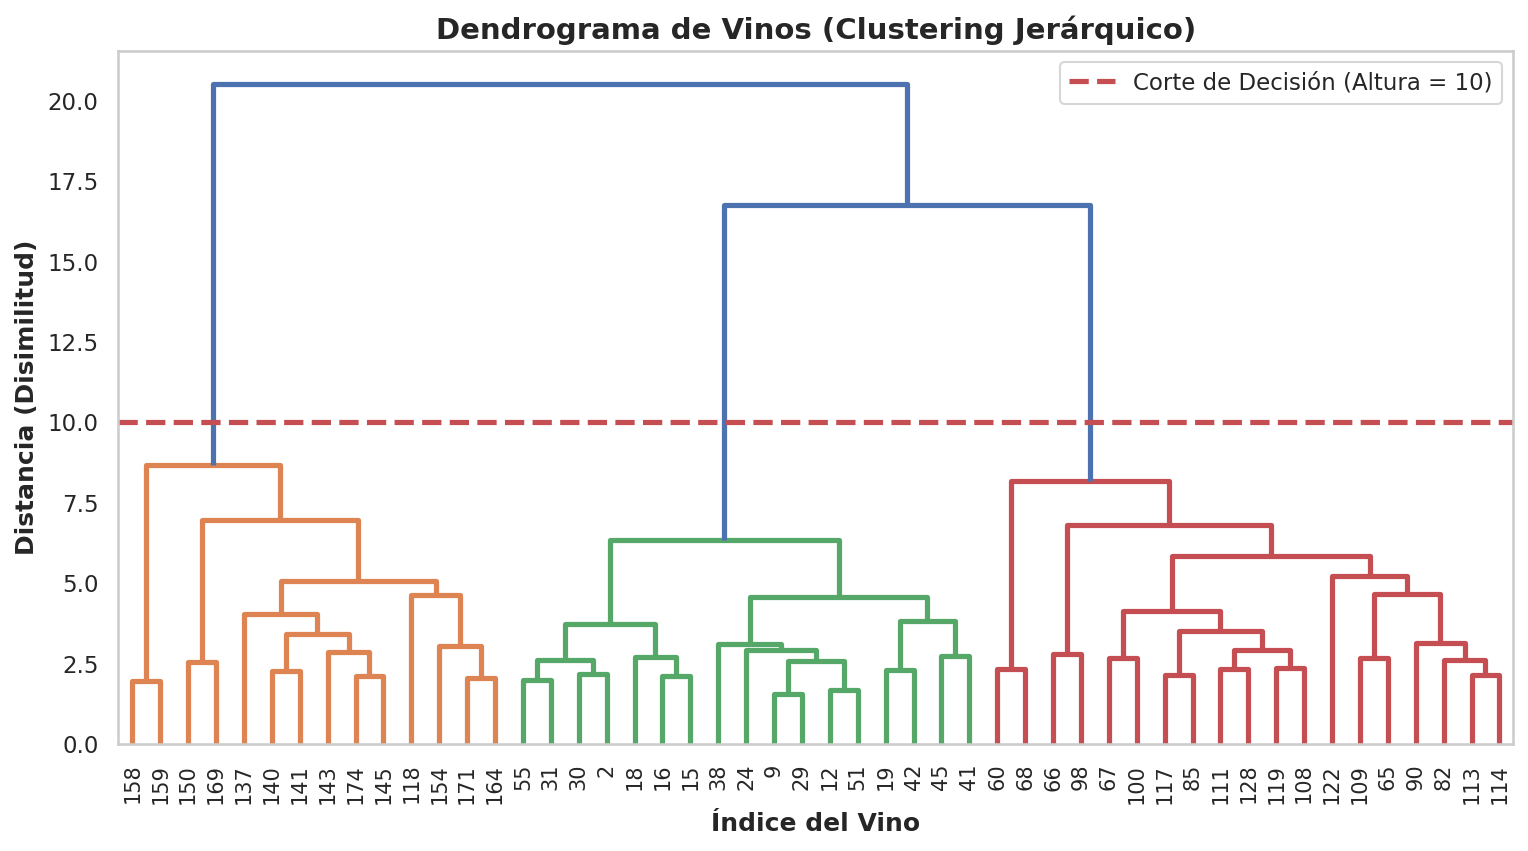

In [15]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import load_wine

# 1. Carga de datos desde datasets de scikit-learn y muestreo
df_wine = load_wine(as_frame=True)
df_wine = df_wine.frame

# Tomamos una muestra aleatoria de 50 vinos para visualizar el árbol claramente
df_sample = df_wine.sample(n=50, random_state=42)

# 2. Estandarización (Obligatorio para calcular distancias)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sample)

# 3. Calculamos la matriz de Linkage (Las uniones jerárquicas)
# method='ward' minimiza la varianza al fusionar clusters (similar a la inercia de K-Means)
matriz_linkage = linkage(X_scaled, method='ward', metric='euclidean')

# 4. Dibujamos el Dendrograma
plt.figure(figsize=(12, 6))
dendrogram(matriz_linkage,
           labels=df_sample.index.tolist(),
           leaf_rotation=90,
           leaf_font_size=10,
           color_threshold=10) # Color_threshold define dónde pintar los clusters

# Dibujamos una línea de corte teórica
plt.axhline(y=10, color='r', linestyle='--', label='Corte de Decisión (Altura = 10)')

plt.title("Dendrograma de Vinos (Clustering Jerárquico)")
plt.xlabel("Índice del Vino")
plt.ylabel("Distancia (Disimilitud)")
plt.grid(False)
plt.legend()
plt.show()

### ¿Cómo leer este gráfico como un Ingeniero?



1. **El Eje Y (Distancia):** Representa qué tan diferentes son los grupos que se están uniendo. Si una línea vertical es muy larga antes de unirse con otra, significa que los grupos que está conectando son muy distintos entre sí.
2. **El Corte:** Busca la línea vertical más larga que no sea cruzada por ninguna línea horizontal extendida. En nuestro gráfico, entre la altura 9 y la 16 hay un gran salto sin fusiones. Si trazamos una línea horizontal de corte en $Y=10$ (la línea roja punteada), cortamos **3 ramas verticales**.
3. **La Conclusión:** El dendrograma nos sugiere visualmente que la taxonomía natural de estos datos se divide en **3 grandes familias de vinos** (y estos, a su vez, en subfamilias).

Una vez que decidimos visualmente que queremos 3 clusters, usamos Scikit-Learn para asignar las etiquetas finales:



In [16]:
# Aplicamos el modelo final pidiendo 3 clusters
modelo_jerarquico = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
etiquetas_vinos = modelo_jerarquico.fit_predict(X_scaled)

print(f"Vinos asignados al Cluster 0: {sum(etiquetas_vinos == 0)}")
print(f"Vinos asignados al Cluster 1: {sum(etiquetas_vinos == 1)}")
print(f"Vinos asignados al Cluster 2: {sum(etiquetas_vinos == 2)}")

Vinos asignados al Cluster 0: 14
Vinos asignados al Cluster 1: 19
Vinos asignados al Cluster 2: 17


## Resultados y Discusión: Criterio de Selección



Ahora conoces tres algoritmos de clustering. ¿Cuándo usar cuál en producción?

1. **K-Means:**
   - *Cuándo usarlo:* Se tienen millones de filas, se necesita velocidad extrema y se sospecha que los grupos son más o menos esféricos.
   - *Costo Computacional:* $O(N)$. Muy rápido.
2. **Gaussian Mixture Models (GMM):**
   - *Cuándo usarlo:* Los datos tienen formas elípticas, varianzas diferentes, o se necesita saber la *probabilidad* de pertenencia (ej. "Este cliente es 80% Perfil A y 20% Perfil B").
   - *Costo Computacional:* Moderado. Más lento que K-Means debido a la estimación de matrices de covarianza.
3. **Clustering Jerárquico:**
   - *Cuándo usarlo:* No se sabe el valor de $K$, se necesita explicar la taxonomía al cliente mediante un Dendrograma, o el dataset es pequeño.
   - *Costo Computacional:* $O(N^3)$ en su forma estándar.
   - ⚠️ **Alerta de Ingeniería:** Jamás intentar hacer un dendrograma con `500.000` filas; la memoria RAM se agota instantáneamente.

## Conexiones y Próximos Pasos


Hemos resuelto el problema de las elipses y el problema de adivinar $K$. Pero, ¿qué pasa si los datos tienen formas completamente arbitrarias, como dos anillos concéntricos o una forma de "S"? Ni K-Means, ni GMM, ni el Clustering Jerárquico con *Ward linkage* podrán resolverlo.

Además, todos estos algoritmos obligan a que **cada punto pertenezca a un cluster**. Si hay un punto de ruido (un *outlier* extremo), lo meterán a la fuerza en el grupo más cercano, arruinando el centroide.

- ➡️ **Siguiente:** En el notebook [Clustering por Densidad (DBSCAN)](15_clustering_por_densidad_dbscan.ipynb), conocemos un algoritmo que agrupa por densidad espacial, capaz de descubrir formas "alienígenas" y, lo más importante, capaz de decir: *"Este punto no pertenece a ningún grupo, es Ruido"*.
- 🔄 **Relacionado:** La capacidad de aislar el ruido que vemos en DBSCAN y es la puerta de entrada perfecta al siguiente bloque del capítulo: la **Detección de Anomalías**.

## Referencias


1. Reynolds, D. A. (2009). *Gaussian mixture models*. Encyclopedia of biometrics, 741(659-663).
2. [Scikit-Learn: Hierarchical clustering](https://scikit-learn.org/stable/modules/clustering.html#hierarchical-clustering)

---


## Entorno de Ejecución


In [17]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
